In [26]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict, Literal

In [27]:
class QuadState(TypedDict):
    
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [ ]:
def show_equation(state:QuadState)->QuadState:
       
       equation = f'{state['a']}x^2{state['b']}x{state['c']}'

       state['equation'] = equation

       return {'equation':equation}

def calculate_discriminant(state:QuadState)-> QuadState:
       
       discriminant = state['b']**2 - (4*state["a"]*state['c'])
          
       return {'discriminant': discriminant}

def real_roots(state:QuadState)->QuadState:

       root1 = (-state['b']+ state['discriminant']**0.5)/(2*state['a'])
       root2 = (-state['b']- state['discriminant']**0.5)/(2*state['a'])

       result = f'The roots are {root1} and {root2}'

       return {'result' : result}



def repeated_roots(state:QuadState)->QuadState:

       root = (-state['b'])/(2*state['a'])
      
       result = f'Only reapeating root is {root}'

       return {'result' : result}


def no_real_roots(state:QuadState)->QuadState:
       
       result = f'The roots are not real'

       return {'result' : result}


def check_condition(state:QuadState)-> Literal["real_roots", "repeated_roots","no_real_roots"] :

       if state['discriminant'] > 0:
              return "real_roots"
       elif(state['discriminant'])==0:
              return "repeated_roots"
       else:
              return "no_real_roots"

In [35]:
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)

graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()



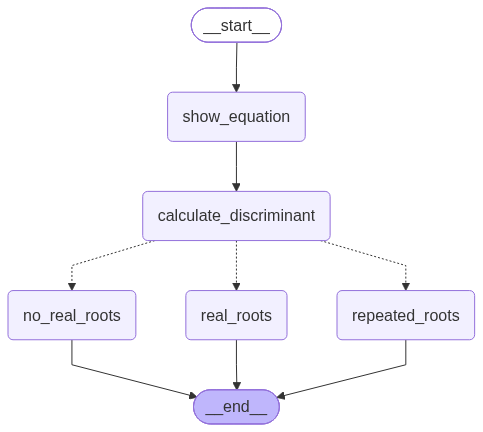

In [36]:
workflow

In [38]:
initial_state = {
    'a':2,
    'b':4,
    'c':2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^24x2',
 'discriminant': 0,
 'result': 'Only reapeating root is -1.0'}